### 门通信方案指标比较

In [1]:
import pandas as pd
df = pd.read_csv('data.csv')


In [2]:
df['name'] = df['name'].str.replace('_\d+', '')
df['name'] = df['name'].apply(lambda x: x.split('_')[0])
df = df[df['FM_DataFlux']>0]

/var/folders/yl/f78zmr7d24n8y70v98h117ww0000gn/T/ipykernel_98024/603832288.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  df['name'] = df['name'].str.replace('_\d+', '')


In [3]:
df = df[df['RawFMDataFlux']>df['FM_DataFlux']]

In [4]:
df = df.sort_values(by=['width','qpu_width','name'])

In [56]:
df.name.replace('v q e','vqe',inplace=True)

In [77]:
df.name = df.name.apply(lambda x : x.upper())

In [78]:
df.name

5       QAOA
3        GHZ
1       QKNN
6        VQE
9       QAOA
16       GHZ
15      QSVM
41       VQE
19    WSTATE
23        BV
8       QAOA
17       GHZ
11      QKNN
12      QSVM
32       VQE
7       QAOA
18       GHZ
10      QKNN
14      QSVM
31       VQE
37        BV
25      QAOA
33       GHZ
27      QKNN
29      QSVM
61       VQE
35    WSTATE
26      QAOA
34       GHZ
28      QKNN
30      QSVM
46       VQE
53        BV
39      QAOA
47       GHZ
42      QKNN
43      QSVM
49    WSTATE
40      QAOA
48       GHZ
44      QKNN
45      QSVM
55      QAOA
57      QKNN
59      QSVM
56      QAOA
58      QKNN
60      QSVM
Name: name, dtype: object

In [79]:
## 根据 width 和 qpu_width 组成一列为新元组
df['width_qpu_width'] = df.apply(lambda x: (x['width'], x['qpu_width']), axis=1)

In [80]:
DataFlux_df = df[['name','width_qpu_width','FM_DataFlux','RawFMDataFlux']]

In [81]:
DataFlux_df = DataFlux_df.sort_values(by=['name','width_qpu_width'])
DataFlux_df.reset_index(drop=True,inplace=True)

In [82]:
DataFlux_df

,name,width_qpu_width,FM_DataFlux,RawFMDataFlux
0,BV,"(30, 10)",8,9
1,BV,"(50, 10)",13,15
2,BV,"(80, 27)",6,12
3,GHZ,"(10, 5)",1,2
4,GHZ,"(30, 5)",5,10
5,GHZ,"(30, 10)",2,5
6,GHZ,"(30, 27)",1,7
7,GHZ,"(50, 10)",4,13
8,GHZ,"(50, 27)",1,3
9,GHZ,"(80, 27)",2,16


In [83]:
import matplotlib.pyplot as plt
import numpy as np
## set dpi
plt.rcParams['figure.dpi'] = 600
## font size
plt.rcParams['font.size'] = 30
## font family
plt.rcParams['font.family'] = 'Times New Roman'
fig, ax = plt.subplots(1,figsize=(30, 10))
colors = ["#F6BE7A","#B8A6D1"]
ax.bar(DataFlux_df.index,DataFlux_df['RawFMDataFlux'],width=0.3,label='Hyper+Autocomm',color=colors[0])
ax.bar(DataFlux_df.index+0.3,DataFlux_df['FM_DataFlux'],width=0.3,label='adaptivedqc',color=colors[1])
ax.set_yscale("log", base = 10)
ax.set_xticks(DataFlux_df.index+0.3/2)
ax.set_xticklabels(DataFlux_df.width_qpu_width,fontsize=30,rotation=90)
ax.grid(axis='y',linestyle='--',
            linewidth=0.5, color='gray', alpha=0.5)
ax.set_xlim(-0.5, len(DataFlux_df.index)-0.2)
ax.set_ylabel('Data Flux',fontsize=35)
plt.legend(loc='best',frameon=False)

In [9]:
## 以两比特门为横轴绘制柱状图 表示DataFlux
import matplotlib.pyplot as plt
import numpy as np
## dpi
plt.rcParams['figure.dpi'] = 600
plt.figure(figsize=(30,10))
## set font Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 30
names = df['name'].unique()
wid = 0.4/len(names)
Maxlen = len(df['width_qpu_width'].unique())
## 利用内置颜色表
colors = plt.cm.tab20(np.linspace(0,1,len(names)))
for i,name in enumerate(names):
    temp = df[df['name']==name].set_index('width_qpu_width')
    temp = temp.reindex(df['width_qpu_width'].unique())
    plt.bar(np.arange(Maxlen)+2*i*wid,temp['FM_DataFlux'], width=wid, label=name,color=colors[i])
    plt.bar(np.arange(Maxlen)+(2*i+0.8)*wid, temp['RawFMDataFlux'], width=wid,hatch='/////',color=colors[i])
plt.xticks(np.arange(Maxlen)+0.3, df['width_qpu_width'].unique())
plt.yscale("log", base = 10)
plt.xlabel('(QC width,QPU width)')
plt.ylabel('DataFlux')
plt.legend()

In [94]:
## Latency Metric compare
import matplotlib.pyplot as plt
import numpy as np
# 绘制Latency Speedup
latency_df = df
latency_df['Latency_Speedup'] = latency_df['RawFMLatency']/latency_df['FM_Latency']
colors = ["#F6BE7A","#B8A6D1"]
colours = ['#DEE4D7',
           "#E3BECA",
           "#FDEDDC",
           "#F7F2BC",
           "#E6ECF3",
           "#FBF5F7",
           '#B3C5DA',
           '#C3B6D9']
## 字体大小设置
## 设置x轴刻度 按照qpu_width和 name 分组
names = latency_df['name'].value_counts().sort_index().index.to_list()
x_label= latency_df['width_qpu_width'].value_counts().sort_index().index.to_list()
fig = plt.figure(figsize=(25, 15))
ax1 = fig.add_subplot(111)
# ##设置x轴的位置刻度
x_index = np.arange(len(x_label))
width = 0.8/len(names)
data_mean = latency_df.groupby(by=['width_qpu_width', 'name']).mean()[['Latency_Speedup','FM_QU','RawFMQU']].reset_index(level=1)
data_max = latency_df.groupby(by=['width_qpu_width', 'name']).max()[[
    'Latency_Speedup','FM_QU','RawFMQU']].reset_index(level=1)
data_min = latency_df.groupby(by=['width_qpu_width', 'name']).min()[[
    'Latency_Speedup','FM_QU','RawFMQU']].reset_index(level=1)
ax2 = ax1.twinx()  # this is the important function
for i in range(len(names)):
    d_min = data_min[data_min['name'] == names[i]][[
    'Latency_Speedup','FM_QU','RawFMQU']]
    d_max = data_max[data_max['name'] == names[i]][[
        'Latency_Speedup','FM_QU','RawFMQU']]
    d_mean = data_mean[data_mean['name'] == names[i]][[
        'Latency_Speedup','FM_QU','RawFMQU']]
    d_max = d_max-d_mean
    d_min = d_mean-d_min
    d_mean = d_mean.reindex(x_label).sort_index()
    d_min = d_min.reindex(x_label).sort_index()
    d_max = d_max.reindex(x_label).sort_index()
    ax1.bar([x+width*i for x in x_index],d_mean['Latency_Speedup'],width=width,color=colours[i], yerr=[d_min['Latency_Speedup'],d_max['Latency_Speedup']],ecolor=colours[4],label=names[i])
    # 绘制y=1的参考线
## 绘制平均值
all_mean = latency_df.mean()[['Latency_Speedup','FM_QU','RawFMQU']]
Avg_id = len(x_label)+0.5
rect = ax1.bar([Avg_id],round(all_mean['Latency_Speedup'],1),width=width,color= '#F3E09D')
ax1.bar_label(rect, padding=3)
data_mean = data_mean.reset_index()
## 设置多维索引保证 QPU width 都有 [5,10,16,27,50,65]
## 构造 name 和QPU width 的多维索引
Mu_index = pd.MultiIndex.from_product(
    [x_label, names], names=['width_qpu_width', 'name'])
data_mean = data_mean.set_index(['width_qpu_width', 'name']).reindex(Mu_index).sort_index()
    ## 绘制QU折线图
Mu_xs = [xi+width*i for xi in x_index for i in range(len(names))]
y1 = (data_mean['FM_QU']*100).to_list()
y2 = (data_mean['RawFMQU']*100).to_list()
ax2.scatter(Mu_xs,y1,marker='^',s=60,label="adaptivedqc", color=colors[1])
ax2.scatter(Mu_xs,y2,marker='h',s=60,label="Hyper+Autocomm",color=colors[0])
for i in range(len(Mu_xs)):
    if y1[i] > y2[i]:
        ax2.plot([Mu_xs[i], Mu_xs[i]], [y1[i], y2[i]], 'g-', lw=1)  # 绿线
    else:
        ax2.plot([Mu_xs[i], Mu_xs[i]], [y1[i], y2[i]], 'r-', lw=1)  # 红线

Avg_data = [all_mean['RawFMQU']*100,all_mean['FM_QU']*100]
ax2.scatter([Avg_id],Avg_data[0],marker='h',s=60,color=colors[0])
ax2.scatter([Avg_id],Avg_data[1],
            marker='^',s=60, color=colors[1])
ax2.annotate(f'{Avg_data[1]:.1f}', xy=(Avg_id,Avg_data[1]),
             xytext=(Avg_id+0.1, Avg_data[1]))
ax2.annotate(f'{Avg_data[0]:.1f}', xy=(Avg_id,Avg_data[0]),
             xytext=(Avg_id+0.1, Avg_data[0]-1))
ax1.hlines(1,x_index.min()-0.1,Avg_id+0.5,color='red', linestyles='dashed')
box = ax1.get_position()
ax1.set_position([box.x0, box.y0, box.width , box.height* 0.8])
ax1.legend(loc='center left', bbox_to_anchor=(0.03, 1.1),ncol=4,frameon=False)
ax1.set_ylabel('Latency Speedup/X',fontsize=35)
x_index = np.append(x_index+0.3,Avg_id)
x_label.append('Average')
ax1.set_xticks(x_index, labels=x_label)
## 设置y轴刻度并设为虚线
ax1.set_ylim(0,5)
ax1.set_yticks([0,1,2,3,4])
ax1.grid(axis='y',linestyle='--',
            linewidth=0.5, color='gray')
ax1.minorticks_on()
box = ax2.get_position()
ax2.set_position([box.x0, box.y0, box.width , box.height* 0.8])
ax2.legend(loc='center right', bbox_to_anchor=(1.0, 1.1),ncol=1,frameon=False)
## 设置
ax2.set_ylabel('QU/%',fontsize=35)
# ax1.set_xlabel("Benchmark",fontsize=35)
## 显示图形
plt.show()

/var/folders/yl/f78zmr7d24n8y70v98h117ww0000gn/T/ipykernel_98024/512961665.py:46: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  all_mean = latency_df.mean()[['Latency_Speedup','FM_QU','RawFMQU']]


In [85]:
fidelity_df = df.groupby(by='name').mean()[['FM_Fidelity','RawFMFidelity']].reset_index()
fidelity_df['RawFM_Error'] = (1-fidelity_df['RawFMFidelity'])*100
fidelity_df['FM_Error'] = (1-fidelity_df['FM_Fidelity'])*100

/var/folders/yl/f78zmr7d24n8y70v98h117ww0000gn/T/ipykernel_98024/1262217450.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  fidelity_df = df.groupby(by='name').mean()[['FM_Fidelity','RawFMFidelity']].reset_index()


Text(0, 0.5, 'Average Error/%')

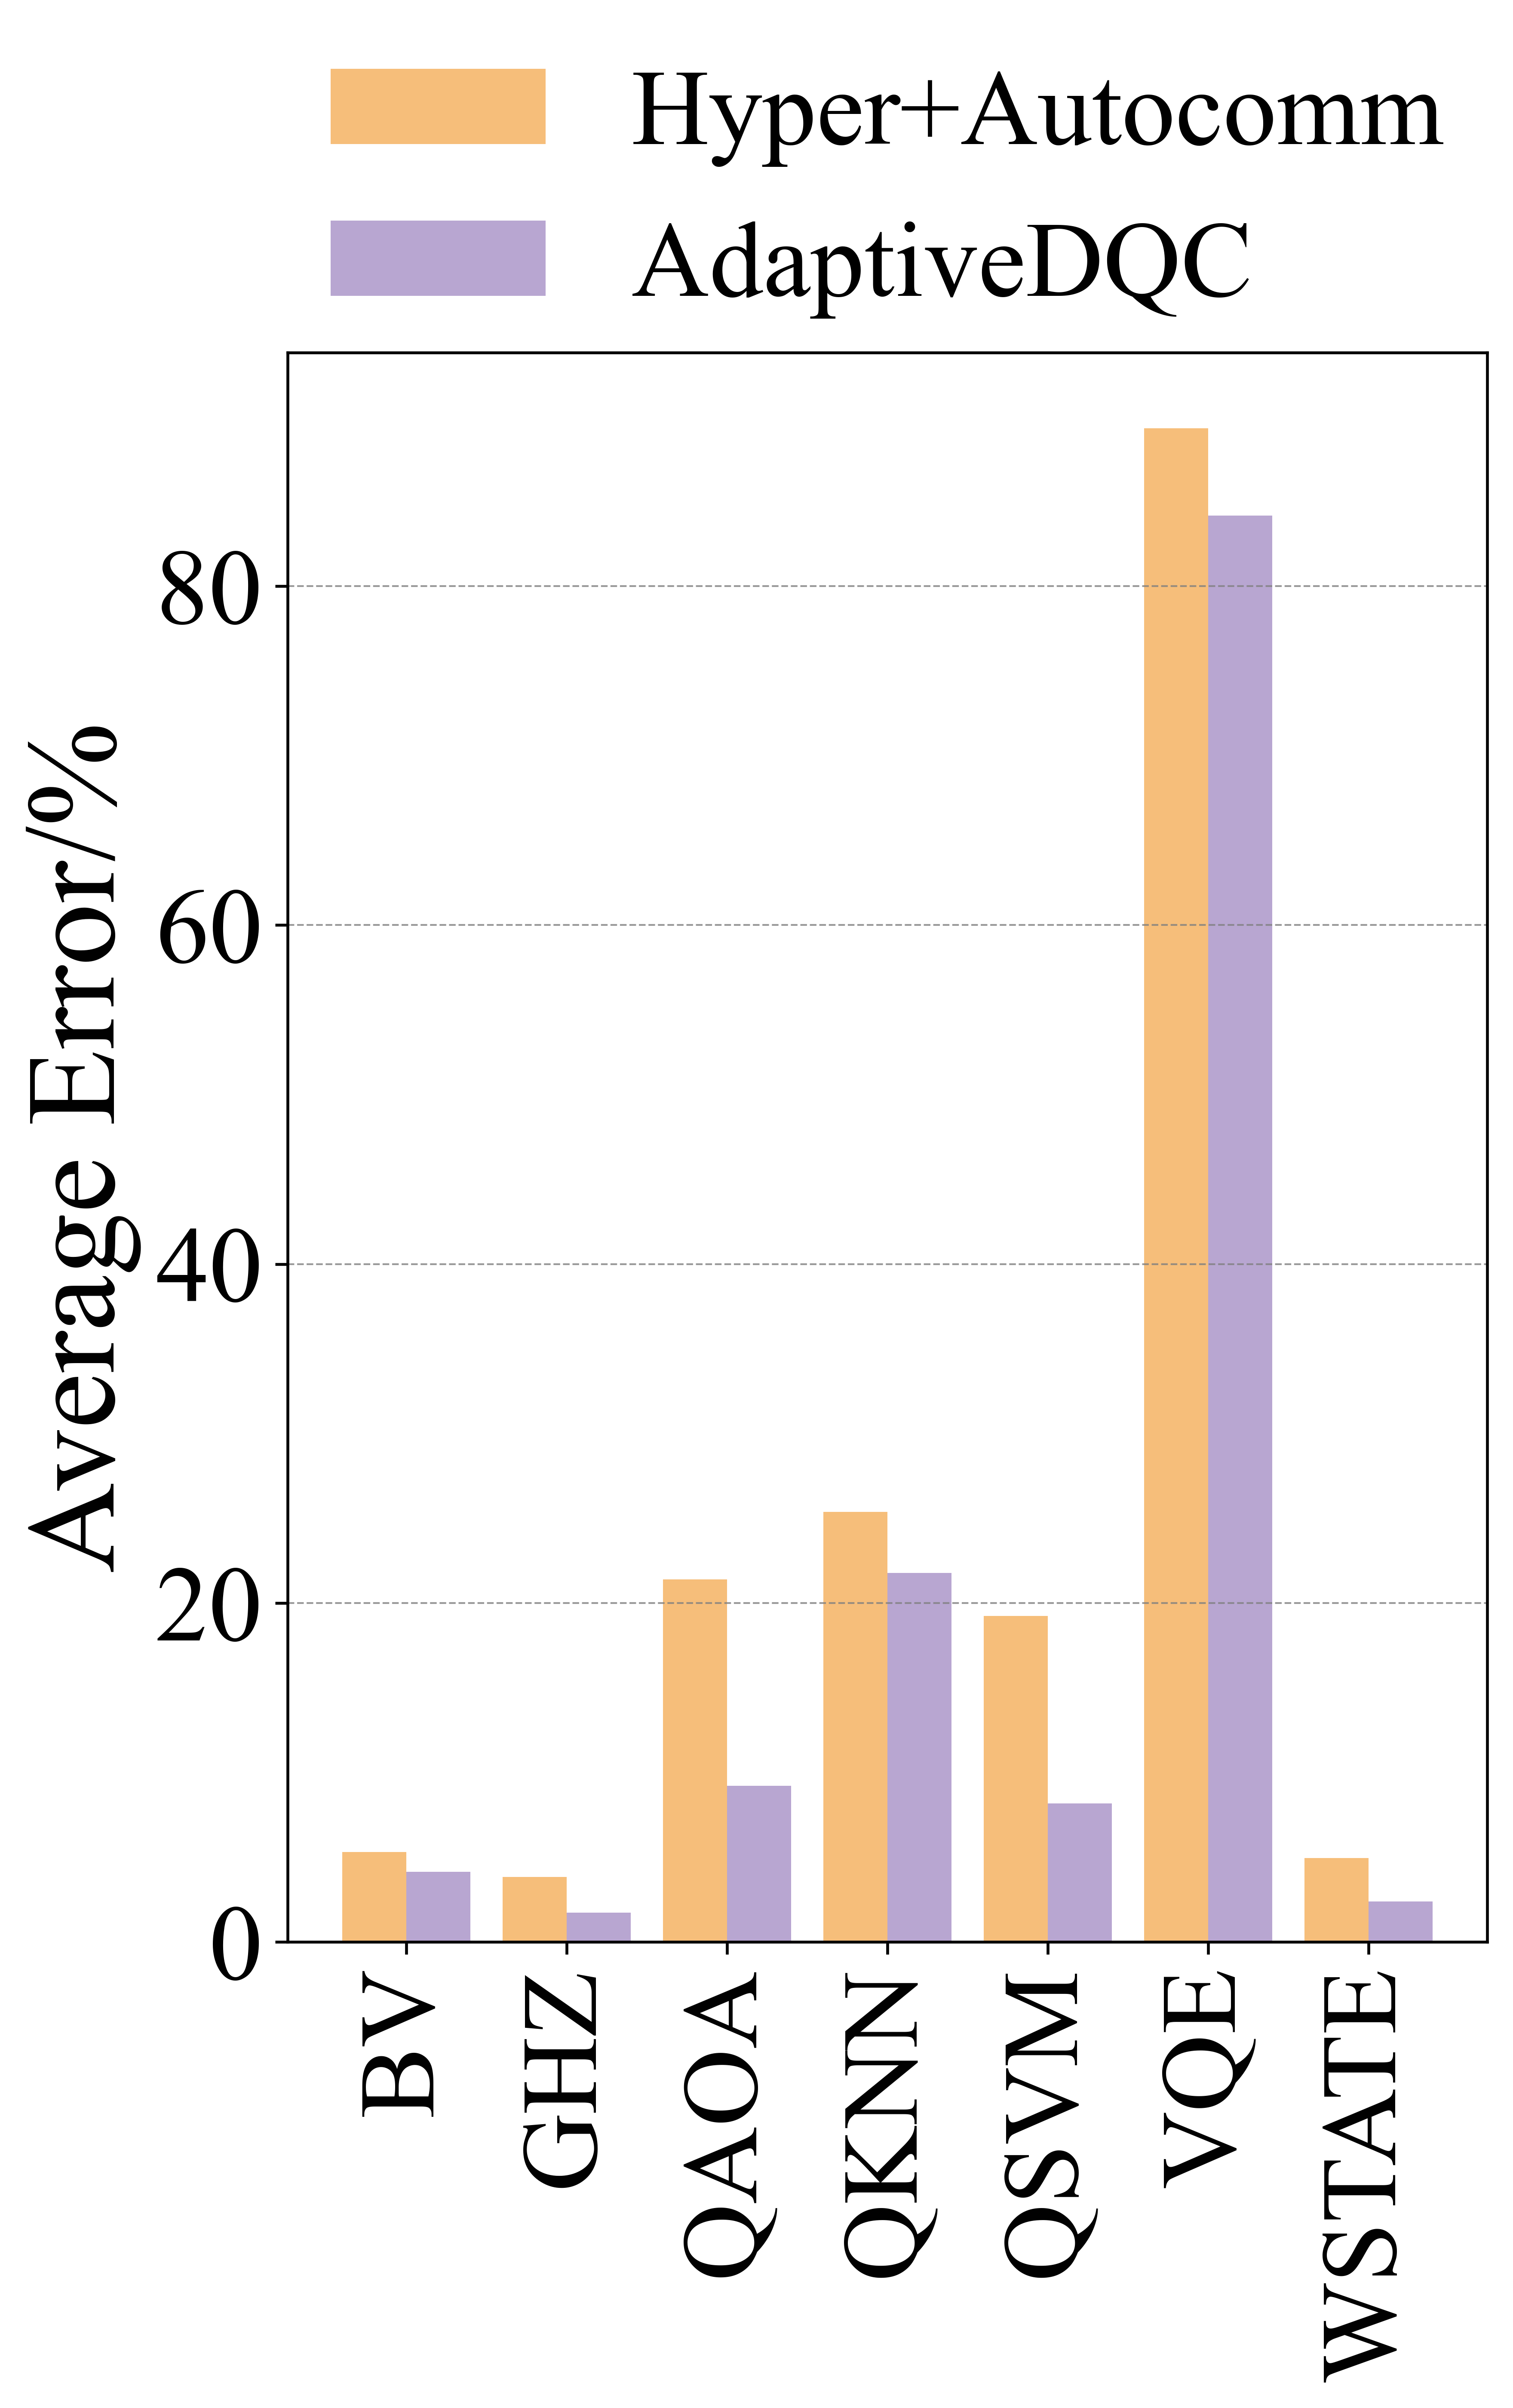

In [89]:
x = np.arange(len(fidelity_df['name']))
fig,ax = plt.subplots(figsize=(6, 10))
ax.set_xticks(x, labels=fidelity_df['name'])
ax.bar(x-0.2,fidelity_df['RawFM_Error'],width=0.4,label='Hyper+Autocomm',color=colors[0])
ax.bar(x+0.2,fidelity_df['FM_Error'],width=0.4,label='adaptivedqc',color=colors[1])
# ax.set_yticks([0,1,2,3,4])
ax.grid(axis='y',linestyle='--',
            linewidth=0.5, color='gray', alpha=0.8)
## rotate the x axis labels
plt.setp(ax.get_xticklabels(), rotation=90)
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width , box.height* 0.8])
ax.legend(loc='center', bbox_to_anchor=(0.5, 1.1),ncol=1,frameon=False)
# ax.set_xlabel('Benchmark',fontsize=35)
ax.set_ylabel('Average Error/%',fontsize=35)

## old test

Text(0.5, 0.98, 'Data Flux lower is better')

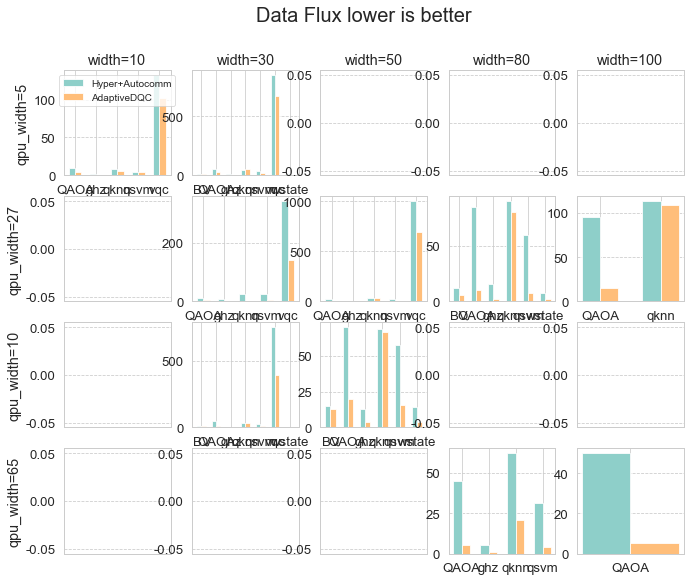

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import matplotlib.ticker as ticker
import matplotlib as mpl
qpu_widths = df.qpu_width.unique()
widths = df.width.unique()
q_num = len(widths)
qpu_num = len(qpu_widths)
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (20*q_num/(q_num+qpu_num), 20*qpu_num/(q_num+qpu_num))
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['font.size'] = 10
## 绘制多个子图 然后无边距的拼在一起
# 绘制数据通量
colors = ['#8ECFC9',
           "#FFBE7A",
           "#FA7F6F",
           "#82B0D2",
           "#BEB8DC",
           "#E7DAD2"]
fig, axs = plt.subplots(len(qpu_widths), len(widths))
fig.subplots_adjust(hspace=0.1, wspace=0.1)
for i in range(len(widths)):
    axs[0,i].set_title(f'width={widths[i]}')
for i in range(len(qpu_widths)):
    axs[i,0].set_ylabel(f'qpu_width={qpu_widths[i]}')
for qpu_width,ax in zip(qpu_widths,axs):
    dfqpu = df[df['qpu_width']==qpu_width]
    for width,ax in zip(widths,ax):
        dfw = dfqpu[dfqpu['width']==width]
        dfw = dfw.sort_values(by=['name'])
        x = np.arange(len(dfw))
        y1 = dfw['RawFMDataFlux']
        y2 = dfw['FM_DataFlux']
        ax.bar(x-0.15,y1,width=0.3,color=colors[0],label='Hyper+Autocomm')
        ax.bar(x+0.15,y2,width=0.3,color=colors[1],label='adaptivedqc')
        # ax.bar(x+0.2,y3,width=0.2,color=colors[2],label='adaptivedqc random')
        
        ax.set_xticks(x)
        ax.set_xticklabels(dfw['name'])
        # ax.legend()
        # max_dataflux = max(y1)
        # ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
        # ax.yaxis.set_minor_locator(ticker.MultipleLocator(2))
        ax.grid(which='major',axis='y',linestyle='--')
        ax.grid(which='minor',axis='y',linestyle=':')

fig.subplots_adjust(hspace=0.2, wspace=0.2)
## 设置图例
axs[0,0].legend(loc='upper center',ncol=1,fontsize=10)
## 设置大标题
fig.suptitle('Data Flux lower is better',fontsize=20)

Text(0.5, 0.98, 'Fidelity Higher is better')

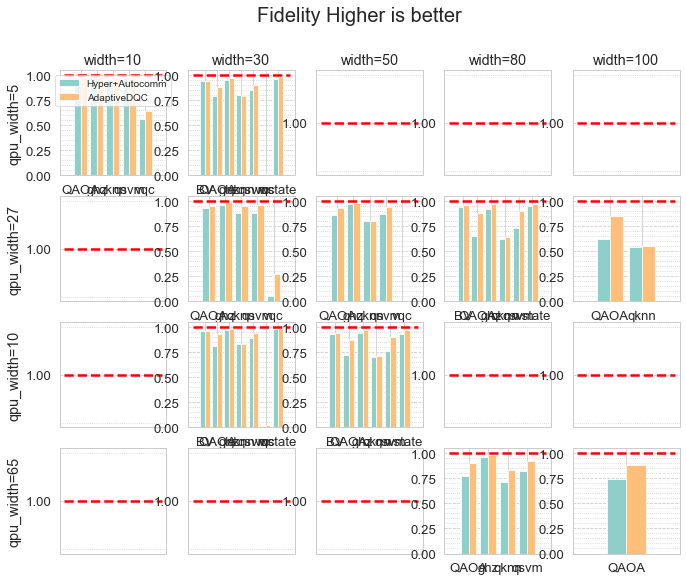

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import matplotlib.ticker as ticker
import matplotlib as mpl
qpu_widths = df.qpu_width.unique()
widths = df.width.unique()
q_num = len(widths)
qpu_num = len(qpu_widths)
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (
    20*q_num/(q_num+qpu_num), 20*qpu_num/(q_num+qpu_num))
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['font.size'] = 10
## 绘制多个子图 然后无边距的拼在一起
# 绘制数据通量
colors = ['#8ECFC9',
          "#FFBE7A",
          "#FA7F6F",
          "#82B0D2",
          "#BEB8DC",
          "#E7DAD2"]
fig, axs = plt.subplots(len(qpu_widths), len(widths))
fig.subplots_adjust(hspace=0.1, wspace=0.1)
for i in range(len(widths)):
    axs[0, i].set_title(f'width={widths[i]}')
for i in range(len(qpu_widths)):
    axs[i, 0].set_ylabel(f'qpu_width={qpu_widths[i]}')
for qpu_width, ax in zip(qpu_widths, axs):
    dfqpu = df[df['qpu_width'] == qpu_width]
    for width, ax in zip(widths, ax):
        dfw = dfqpu[dfqpu['width'] == width]
        dfw = dfw.sort_values(by=['name'])
        x = np.arange(len(dfw))
        y1 = dfw['RawFMFidelity']
        y2 = dfw['FM_Fidelity']
        ax.bar(x-0.2, y1, width=0.4, color=colors[0], label='Hyper+Autocomm')
        ax.bar(x+0.2, y2, width=0.4, color=colors[1], label='adaptivedqc')
        ax.set_xticks(x)
        ax.set_xticklabels(dfw['name'])
        # ax.legend()
        ax.hlines(1, -1, len(dfw), colors='r', linestyles='dashed')
        ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
        ax.grid(which='major', axis='y', linestyle='--')
        ax.grid(which='minor', axis='y', linestyle=':')
        ax.ylimit = (0, 1)

fig.subplots_adjust(hspace=0.2, wspace=0.2)
## 设置图例
axs[0, 0].legend(loc='upper center', ncol=1, fontsize=10)
fig.suptitle('Fidelity Higher is better',fontsize=20)

## latency

In [18]:
df['Latency_ratio'] = (1-df['FM_Latency']/df['RawFMLatency'])*100
df['QU_ratio'] = (df['FM_QU']/df['RawFMQU']-1)*100
df[['Latency_ratio','QU_ratio']]

,Latency_ratio,QU_ratio
0,0.000000,11.287469
1,30.610203,32.468015
3,43.527738,43.558720
5,15.239044,65.591472
6,13.089976,5.093522
7,13.903986,105.402638
8,60.380406,50.883208
9,46.836735,40.209521
10,67.840867,133.817698
11,5.190399,102.669851


([<matplotlib.axis.YTick at 0x7fa251a27340>,
 [Text(0, 0.5, '(10, 5)'),
  Text(0, 1.5, '(30, 5)'),
  Text(0, 2.5, '(30, 10)'),
  Text(0, 3.5, '(30, 27)'),
  Text(0, 4.5, '(50, 10)'),
  Text(0, 5.5, '(50, 27)'),
  Text(0, 6.5, '(80, 27)'),
  Text(0, 7.5, '(80, 65)'),
  Text(0, 8.5, '(100, 27)'),
  Text(0, 9.5, '(100, 65)')])

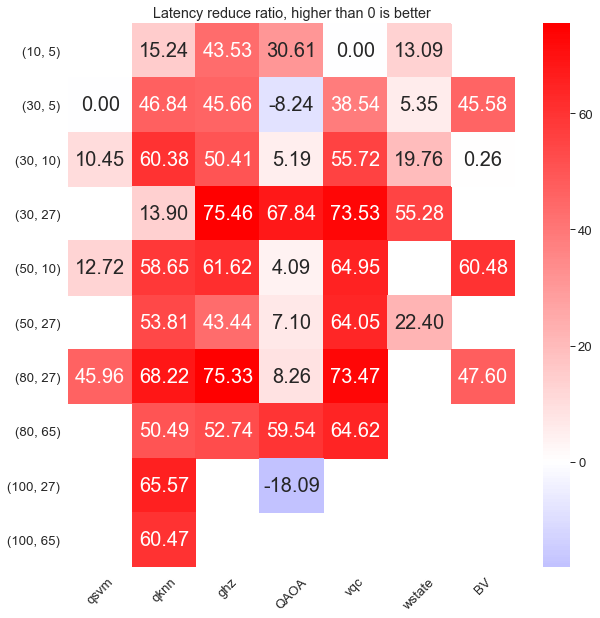

In [19]:
## heatmap
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# 开始绘制
plt.rcParams['font.size'] = 20
plt.rcParams['figure.figsize'] = (20, 20)
plt.figure(figsize=(10, 10))
pivot_table = df.pivot_table(index=['width', 'qpu_width'],
               columns='name', values='Latency_ratio')
sns.heatmap(pivot_table.to_numpy(), annot=True, fmt='.2f', cmap='bwr', center=0)
plt.title('Latency reduce ratio, higher than 0 is better')
## 设置坐标轴
plt.xticks(np.arange(0.5, len(df.name.unique()), 1), df.name.unique(), rotation=45)
plt.yticks(np.arange(0.5,len(pivot_table) , 1), df.pivot_table(index=['width','qpu_width'],columns='name',values='Latency_ratio').index, rotation=0)

([<matplotlib.axis.YTick at 0x7fa2556801c0>,
 [Text(0, 0.5, '(10, 5)'),
  Text(0, 1.5, '(30, 5)'),
  Text(0, 2.5, '(30, 10)'),
  Text(0, 3.5, '(30, 27)'),
  Text(0, 4.5, '(50, 10)'),
  Text(0, 5.5, '(50, 27)'),
  Text(0, 6.5, '(80, 27)'),
  Text(0, 7.5, '(80, 65)'),
  Text(0, 8.5, '(100, 27)'),
  Text(0, 9.5, '(100, 65)')])

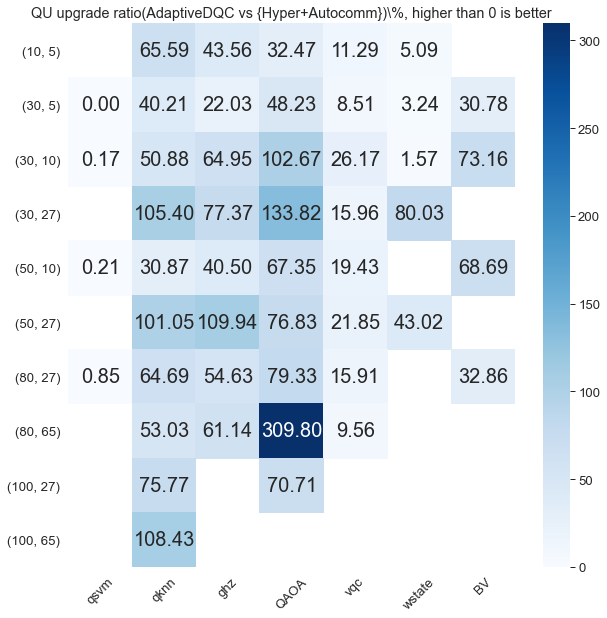

In [20]:
## heatmap
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# 开始绘制
## 设置字号
plt.rcParams['font.size'] = 20
plt.figure(figsize=(10, 10))
pivot_table = df.pivot_table(index=['width', 'qpu_width'],
               columns='name', values='QU_ratio')
sns.heatmap(pivot_table.to_numpy(), annot=True, fmt='.2f', cmap='Blues')
plt.title('QU upgrade ratio(adaptivedqc vs {Hyper+Autocomm})\%, higher than 0 is better')
## 设置坐标轴
plt.xticks(np.arange(0.5, len(df.name.unique()), 1), df.name.unique(), rotation=45)
plt.yticks(np.arange(0.5,len(pivot_table) , 1), df.pivot_table(index=['width','qpu_width'],columns='name',values='QU_ratio').index, rotation=0)